# Prediction Inspection

> **⚠ Running on fabricated data.** No real SIESTA samples are present yet. This notebook
> quick-trains a tiny model on synthetic molecules so the plotting path is exercised. Once real
> data lands, build `dataset.pkl` + `params.msgpack` (see README) and this notebook will load
> them automatically — **no code changes**.

In [1]:
%matplotlib inline
import demo_utils  # noqa: F401 — puts the repo root on sys.path
from pathlib import Path
import numpy as np, jax, matplotlib.pyplot as plt
from demo_utils import DEMO_CONFIG, demo_molecule, fabricate_wannier, plot_molecule
from model.model import model_from_config
from training.loss import example_to_jax
from training.train import train, load_params
from data.dataset import load_cache

have_real = Path("../params.msgpack").exists() and Path("../dataset.pkl").exists()
if have_real:
    examples, meta = load_cache("../dataset.pkl")
    cfg = {**DEMO_CONFIG}
    cfg["wannier"] = {**cfg["wannier"],
                      "max_centers": max(cfg["wannier"]["max_centers"], meta["max_centers"])}
    model = model_from_config(cfg)
    ex_j = [example_to_jax(e) for e in examples]
    params = load_params("../params.msgpack",
                         model.init(jax.random.PRNGKey(0), ex_j[0]["z"], ex_j[0]["pos"]))
    print(f"loaded {len(examples)} real molecules + trained params")
else:
    z, pos0 = demo_molecule(); rng = np.random.default_rng(0)
    examples = []
    for k in range(6):
        p = pos0 + rng.standard_normal(pos0.shape) * 0.1
        examples.append({"z": z, "pos": p, "energy": np.float64(-100 - 8 * k),
                         "wannier": fabricate_wannier(p, seed=k)})
    cfg = DEMO_CONFIG
    params = train(cfg, examples)                 # quick inline train
    model = model_from_config(cfg)
    ex_j = [example_to_jax(e) for e in examples]

epoch    0  val energy MAE = 106.7808 eV


epoch   10  val energy MAE = 12.6204 eV


epoch   20  val energy MAE = 10.1028 eV


epoch   30  val energy MAE = 4.3104 eV


## Energy parity — predicted vs true

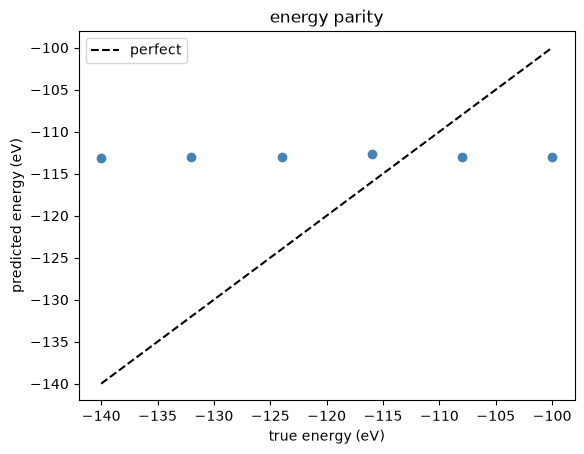

In [2]:
apply = model.apply
pe = [float(apply(params, e["z"], e["pos"])["energy"]) for e in ex_j]
te = [float(e["energy"]) for e in ex_j]
plt.scatter(te, pe, c="steelblue")
lim = [min(te + pe), max(te + pe)]; plt.plot(lim, lim, "k--", label="perfect")
plt.xlabel("true energy (eV)"); plt.ylabel("predicted energy (eV)")
plt.title("energy parity"); plt.legend(); plt.show()

## Center overlay — predicted (orange ▲) vs true (green ✕) for one molecule

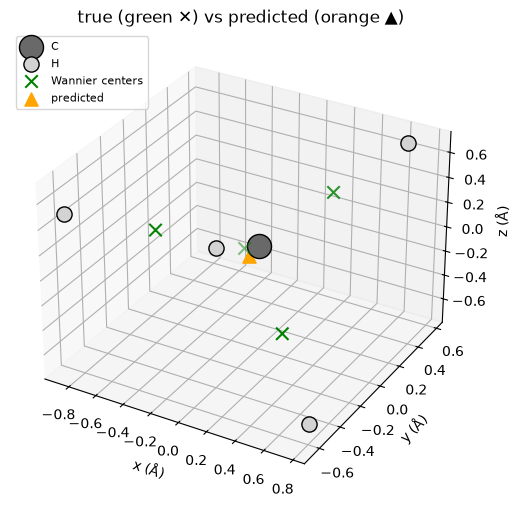

In [3]:
e = ex_j[0]; out = apply(params, e["z"], e["pos"])
fig = plt.figure(figsize=(6, 6)); ax = fig.add_subplot(111, projection="3d")
plot_molecule(ax, e["z"], e["pos"], np.asarray(e["wannier"][0]["centers"]),
              title="true (green ✕) vs predicted (orange ▲)", center_color="green")
pc = np.asarray(out["wannier"]["centers"])[0]
keep = np.asarray(out["wannier"]["presence"])[0] > 0.5
ax.scatter(pc[keep, 0], pc[keep, 1], pc[keep, 2], c="orange", marker="^", s=90,
           label="predicted")
ax.legend(loc="upper left", fontsize=8); plt.show()

### Note

On fabricated data the numbers are meaningless — this only proves the **inspection path** runs.
The value of this notebook arrives with real SIESTA outputs.